STATISTIQUES DESCRIPTIVES DU PROJET BOSON DE HIGGS

In [1]:
#IMPORTATION DES BIBLIOTHEQUES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
#IMPORTATION DU TRAIN
train=pd.read_csv("training.csv")
train.head(5)

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


ANALYSE EXPLORATOIRE DES VARIABLES

RESUME GLOBAL DES DONNEES

In [3]:
df = train.copy()

# Nombre d'événements
nombre_evenements = df.shape[0]

# Nombre de variables
nombre_colonnes_total = df.shape[1]
nombre_variables_explicatives = df.drop(columns=['EventId', 'Label', 'Weight']).shape[1]

# Distribution des labels
comptage_labels = df['Label'].value_counts()
proportions_labels = df['Label'].value_counts(normalize=True) * 100

# Nombre d'événements signal / bruit
nombre_signal = comptage_labels.get('s', 0)
nombre_bruit = comptage_labels.get('b', 0)

# Taux global de valeurs manquantes (-999)
colonnes_variables = [col for col in df.columns if col not in ['EventId', 'Label', 'Weight']]

nombre_valeurs_total = df[colonnes_variables].size
nombre_valeurs_manquantes = (df[colonnes_variables] == -999).sum().sum()
taux_valeurs_manquantes = nombre_valeurs_manquantes / nombre_valeurs_total * 100

# Résumé global
resume_global = {
    "Nombre total d'événements": nombre_evenements,
    "Nombre total de colonnes": nombre_colonnes_total,
    "Nombre de variables explicatives": nombre_variables_explicatives,
    "Nombre d'événements signal (Label = s)": nombre_signal,
    "Nombre d'événements bruit (Label = b)": nombre_bruit,
    "Proportion signal (%)": round(proportions_labels.get('s', 0), 2),
    "Proportion bruit (%)": round(proportions_labels.get('b', 0), 2),
    "Taux global de valeurs manquantes (-999) (%)": round(taux_valeurs_manquantes, 2)
}

pd.Series(resume_global)

Nombre total d'événements                       250000.00
Nombre total de colonnes                            33.00
Nombre de variables explicatives                    30.00
Nombre d'événements signal (Label = s)           85667.00
Nombre d'événements bruit (Label = b)           164333.00
Proportion signal (%)                               34.27
Proportion bruit (%)                                65.73
Taux global de valeurs manquantes (-999) (%)        21.07
dtype: float64

In [4]:
# Copie des données
donnees = train.copy()

# Colonnes à exclure
colonnes_exclues = ["EventId", "Weight", "Label"]
colonnes_variables = [col for col in donnees.columns if col not in colonnes_exclues]

# Conversion explicite si nécessaire
donnees['PRI_jet_subleading_pt'] = pd.to_numeric(
    donnees['PRI_jet_subleading_pt'], errors='coerce'
)

resume_variables = []

for colonne in colonnes_variables:
    serie = donnees[colonne]

    # Valeurs manquantes codées en -999
    valeurs_manquantes = serie == -999
    pourcentage_manquant = valeurs_manquantes.mean() * 100

    # Valeurs valides (hors -999)
    valeurs_valides = serie[~valeurs_manquantes]

    # Nombre de valeurs uniques
    nombre_valeurs_uniques = valeurs_valides.nunique()

    # Typologie physique 
    if 'phi' in colonne.lower():
        type_variable = 'Angulaire'

    elif nombre_valeurs_uniques <= 10:
        type_variable = 'Quasi-discrète'

    elif colonne.startswith('DER_'):
        type_variable = 'Dérivée'

    elif colonne.startswith('PRI_'):
        type_variable = 'Continue (primaire)'

    else:
        type_variable = 'Continue'

    resume_variables.append({
        'Variable': colonne,
        'Type de variable': type_variable,
        'Nombre de valeurs uniques': nombre_valeurs_uniques,
        'Pourcentage de valeurs manquantes (%)': round(pourcentage_manquant, 2)
    })

# Création du DataFrame final
tableau_resume = pd.DataFrame(resume_variables)

# Tri par taux de valeurs manquantes
tableau_resume = tableau_resume.sort_values(
    by='Pourcentage de valeurs manquantes (%)',
    ascending=False
).reset_index(drop=True)

tableau_resume

,Variable,Type de variable,Nombre de valeurs uniques,Pourcentage de valeurs manquantes (%)
0,DER_deltaeta_jet_jet,Dérivée,7086,70.98
1,DER_mass_jet_jet,Dérivée,68365,70.98
2,DER_lep_eta_centrality,Dérivée,1001,70.98
3,DER_prodeta_jet_jet,Dérivée,16592,70.98
4,PRI_jet_subleading_pt,Continue (primaire),42463,70.98
5,PRI_jet_subleading_phi,Angulaire,6285,70.98
6,PRI_jet_subleading_eta,Continue (primaire),8627,70.98
7,PRI_jet_leading_pt,Continue (primaire),86589,39.97
8,PRI_jet_leading_eta,Continue (primaire),8557,39.97
9,PRI_jet_leading_phi,Angulaire,6284,39.97


<class 'pandas.Series'>


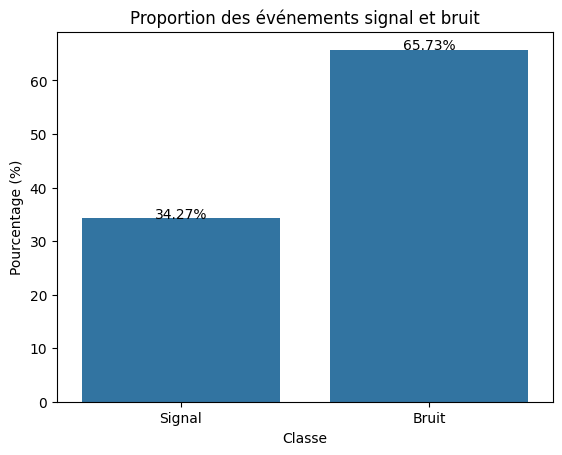

In [5]:
donnees = train.copy()

# Vérification
assert 'Label' in donnees.columns, "La colonne 'Label' est absente"

# Calcul des proportions
comptage = donnees['Label'].value_counts(normalize=True)

print(type(comptage))  # doit être pandas Series

proportions_classes = (
    comptage
    .reindex(['s', 'b'], fill_value=0)
    .mul(100)
    .rename_axis('Classe')
    .reset_index(name='Pourcentage')
)

# Remplacement noms
proportions_classes['Classe'] = proportions_classes['Classe'].replace({
    's': 'Signal',
    'b': 'Bruit'
})

# Graphique
ax = sns.barplot(data=proportions_classes, x='Classe', y='Pourcentage')

ax.set_title("Proportion des événements signal et bruit")
ax.set_ylabel("Pourcentage (%)")

for i, row in proportions_classes.iterrows():
    ax.text(i, row['Pourcentage'], f"{row['Pourcentage']:.2f}%", ha='center')

plt.show()

ANALYSE DE LA SEULE VARIABLE CONSIDEREE DISCRETE

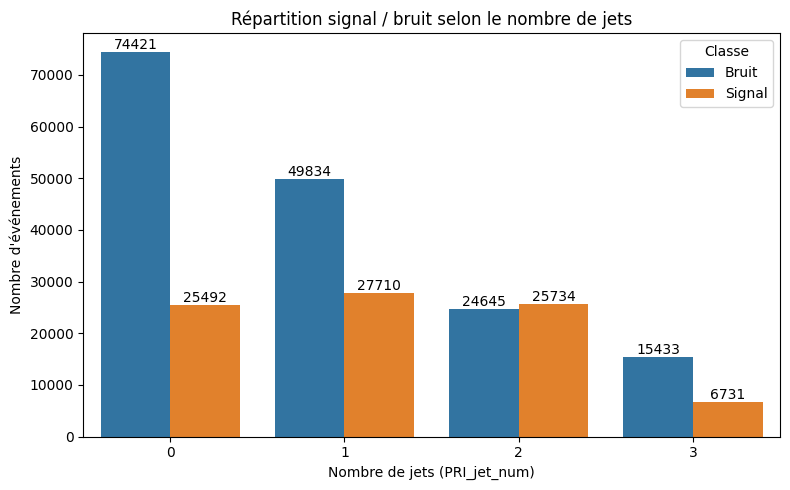

In [6]:
# Copie des données
donnees = train.copy()

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=donnees,
    x='PRI_jet_num',
    hue='Label'
)

ax.set_title("Répartition signal / bruit selon le nombre de jets")
ax.set_xlabel("Nombre de jets (PRI_jet_num)")
ax.set_ylabel("Nombre d'événements")

plt.legend(title="Classe", labels=["Bruit", "Signal"])

# Ajouter les valeurs sur les barres
for barre in ax.patches:
    hauteur = barre.get_height()
    if hauteur > 0:
        ax.annotate(
            f'{int(hauteur)}',
            (barre.get_x() + barre.get_width() / 2, hauteur),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

CREATION DES 4 DATAFRAMES SELON LES JETS NUMS

In [7]:
# Copie des données
donnees = train.copy()

# Création des 4 DataFrames
jet_0 = donnees[donnees['PRI_jet_num'] == 0].copy()
jet_1 = donnees[donnees['PRI_jet_num'] == 1].copy()
jet_2 = donnees[donnees['PRI_jet_num'] == 2].copy()
jet_3 = donnees[donnees['PRI_jet_num'] == 3].copy()

NETTOYAGE DES DATAFRAMES

Je supprime les colonnes qui possèdent les valeurs -999

In [8]:
def nettoyer_colonnes(df, seuil=0.8):
    colonnes_exclues = ['EventId', 'Weight', 'Label', 'PRI_jet_num']
    
    colonnes_a_supprimer = []
    
    for col in df.columns:
        if col in colonnes_exclues:
            continue
        
        proportion_nan = (df[col] == -999).mean()
        
        if proportion_nan > seuil:
            colonnes_a_supprimer.append(col)
    
    return df.drop(columns=colonnes_a_supprimer)

In [9]:
jet_0 = nettoyer_colonnes(jet_0)
jet_1 = nettoyer_colonnes(jet_1)
jet_2 = nettoyer_colonnes(jet_2)
jet_3 = nettoyer_colonnes(jet_3)

In [10]:
jet_1.shape

(77544, 26)

POUVOIR DISCRIMINANT DE CHAQUE VARIABLE

In [11]:
# Organisation des données par nombre de jets
donnees_par_jet = {
    "0 jet": jet_0,
    "1 jet": jet_1,
    "2 jets": jet_2,
    "3 jets": jet_3
}

In [12]:
# Fonction pour calculer l'AUC de chaque variable

def calculer_auc_variables(donnees_jet):
    
    # Colonnes à exclure
    colonnes_exclues = ["EventId", "Weight", "Label", "PRI_jet_num"]
    
    # Variables explicatives
    colonnes_variables = [
        col for col in donnees_jet.columns 
        if col not in colonnes_exclues
    ]
    
    # Encodage du label
    y = donnees_jet["Label"].map({"s": 1, "b": 0})
    
    resultats_auc = []
    
    for colonne in colonnes_variables:
        
        # On travaille sur une variable à la fois
        sous_donnees = donnees_jet[[colonne]].copy()
        sous_donnees["Label_binaire"] = y
        
        # Suppression des valeurs -999
        sous_donnees = sous_donnees[sous_donnees[colonne] != -999]
        
        # Vérifications de base
        if sous_donnees.shape[0] < 100:
            continue
        
        if sous_donnees["Label_binaire"].nunique() < 2:
            continue
        
        y_vrai = sous_donnees["Label_binaire"]
        score_variable = sous_donnees[colonne]
        
        # Calcul AUC
        auc_brute = roc_auc_score(y_vrai, score_variable)
        
        # Correction si inversée
        auc_corrigee = max(auc_brute, 1 - auc_brute)
        
        resultats_auc.append({
            "Variable": colonne,
            "AUC brute": round(auc_brute, 4),
            "AUC corrigée": round(auc_corrigee, 4),
            "Distance à 0.5": round(abs(auc_brute - 0.5), 4),
            "Sens de séparation": "Signal > bruit" if auc_brute >= 0.5 else "Signal < bruit"
        })
    
    # Création du tableau final
    tableau_auc = pd.DataFrame(resultats_auc)
    
    # Tri par pouvoir discriminant
    tableau_auc = tableau_auc.sort_values(
        by="AUC corrigée",
        ascending=False
    ).reset_index(drop=True)
    
    return tableau_auc

In [13]:
# Calcul des AUC pour chaque groupe de jets

auc_jet_0 = calculer_auc_variables(jet_0)
auc_jet_1 = calculer_auc_variables(jet_1)
auc_jet_2 = calculer_auc_variables(jet_2)
auc_jet_3 = calculer_auc_variables(jet_3)

auc_par_jet = {
    "0 jet": auc_jet_0,
    "1 jet": auc_jet_1,
    "2 jets": auc_jet_2,
    "3 jets": auc_jet_3
}

In [14]:
# Affichage du top 5 des variables

for nom_jet, tableau_auc in auc_par_jet.items():
    print("\n")
    print(f"Top 5 — {nom_jet}")
    print(tableau_auc.head(5).to_string(index=False))



Top 5 — 0 jet
                   Variable  AUC brute  AUC corrigée  Distance à 0.5 Sens de séparation
DER_mass_transverse_met_lep     0.2020        0.7980          0.2980     Signal < bruit
       DER_pt_ratio_lep_tau     0.2506        0.7494          0.2494     Signal < bruit
                 PRI_tau_pt     0.7411        0.7411          0.2411     Signal > bruit
                    PRI_met     0.2715        0.7285          0.2285     Signal < bruit
         DER_deltar_tau_lep     0.6694        0.6694          0.1694     Signal > bruit


Top 5 — 1 jet
                   Variable  AUC brute  AUC corrigée  Distance à 0.5 Sens de séparation
DER_mass_transverse_met_lep     0.3045        0.6955          0.1955     Signal < bruit
                 PRI_tau_pt     0.6704        0.6704          0.1704     Signal > bruit
               DER_mass_MMC     0.6566        0.6566          0.1566     Signal > bruit
     DER_met_phi_centrality     0.6477        0.6477          0.1477     Signal > bruit


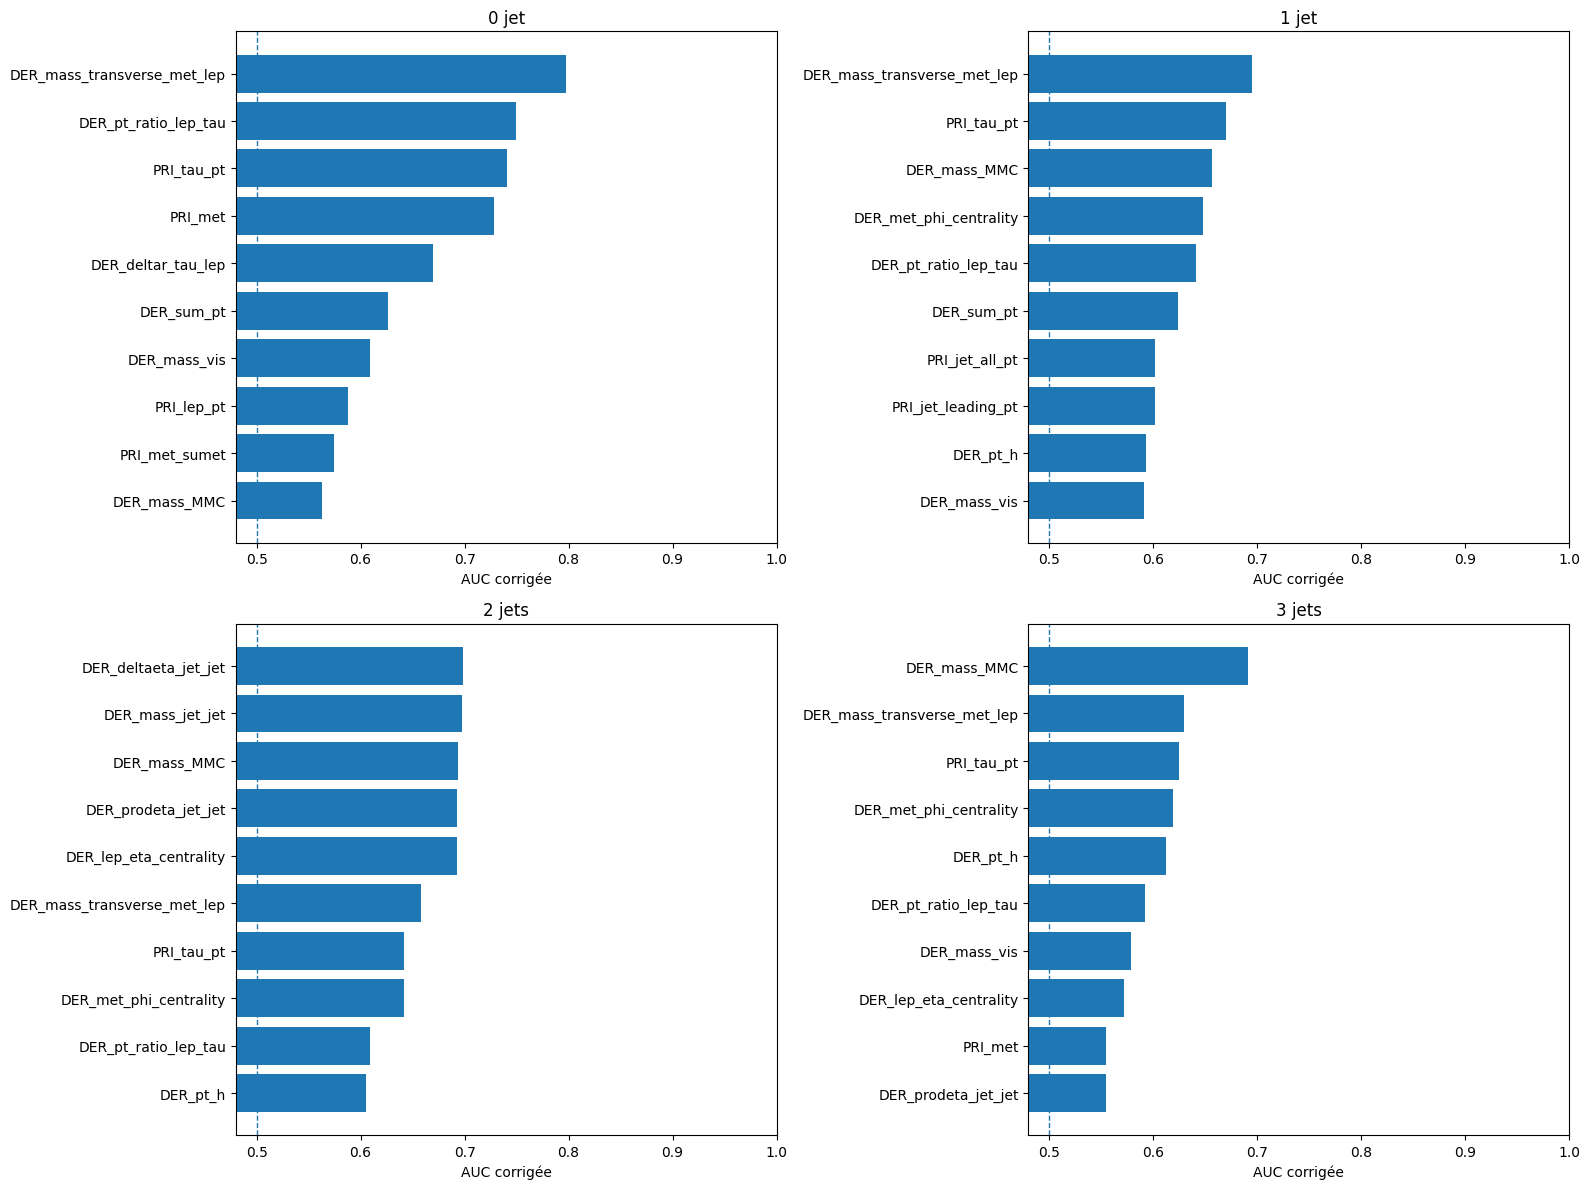

In [15]:
# Graphique : top 10 des variables par jet

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for axe, (nom_jet, tableau_auc) in zip(axes, auc_par_jet.items()):
    
    top_variables = tableau_auc.head(10).sort_values(
        by="AUC corrigée",
        ascending=True
    )
    
    axe.barh(
        top_variables["Variable"],
        top_variables["AUC corrigée"]
    )
    
    axe.axvline(0.5, linestyle="--", linewidth=1)
    axe.set_title(f"{nom_jet}")
    axe.set_xlabel("AUC corrigée")
    axe.set_xlim(0.48, 1.0)

plt.tight_layout()
plt.show()

In [16]:
# Colonnes à exclure
colonnes_exclues = ["Label", "Weight", "EventId", "PRI_jet_num"]

# Organisation des données
donnees_par_jet = {
    "0 jet": jet_0,
    "1 jet": jet_1,
    "2 jets": jet_2,
    "3 jets": jet_3
}

In [17]:
# Fonction simple pour calculer et afficher la corrélation

def afficher_matrice_correlation(donnees_jet, nom_jet, seuil_correlation=0.85):
    
    colonnes_variables = [
        col for col in donnees_jet.columns
        if col not in colonnes_exclues
    ]
    
    X = donnees_jet[colonnes_variables]
    
    matrice_correlation = X.corr(method="spearman")
    
    plt.figure(figsize=(12, 9))
    
    masque = np.triu(np.ones_like(matrice_correlation, dtype=bool))
    
    sns.heatmap(
        matrice_correlation,
        mask=masque,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7}
    )
    
    plt.title(f"Corrélation — {nom_jet}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
    paires_redondantes = []
    
    for i in range(len(matrice_correlation.columns)):
        for j in range(i + 1, len(matrice_correlation.columns)):
            
            corr = matrice_correlation.iloc[i, j]
            
            if abs(corr) >= seuil_correlation:
                paires_redondantes.append({
                    "Variable 1": matrice_correlation.columns[i],
                    "Variable 2": matrice_correlation.columns[j],
                    "Corrélation": round(corr, 3)
                })
    
    tableau_paires = pd.DataFrame(paires_redondantes)
    
    return matrice_correlation, tableau_paires

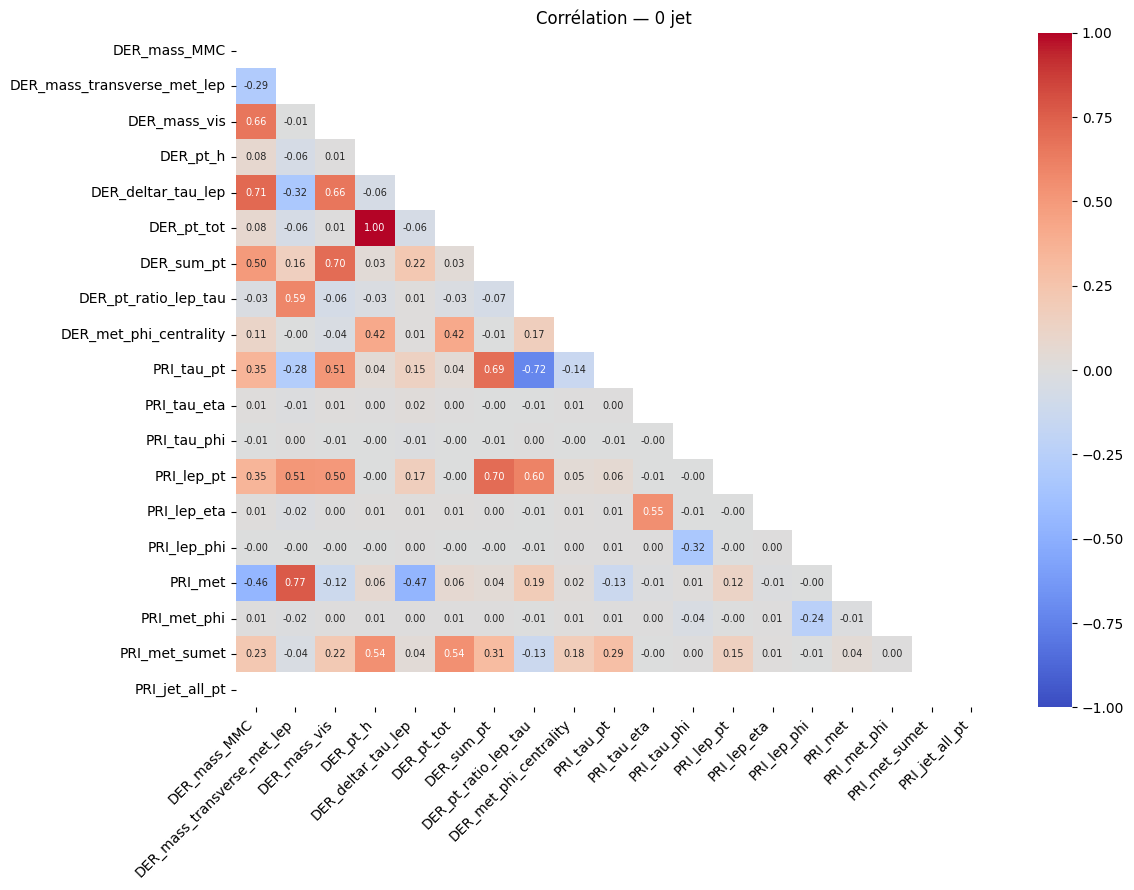

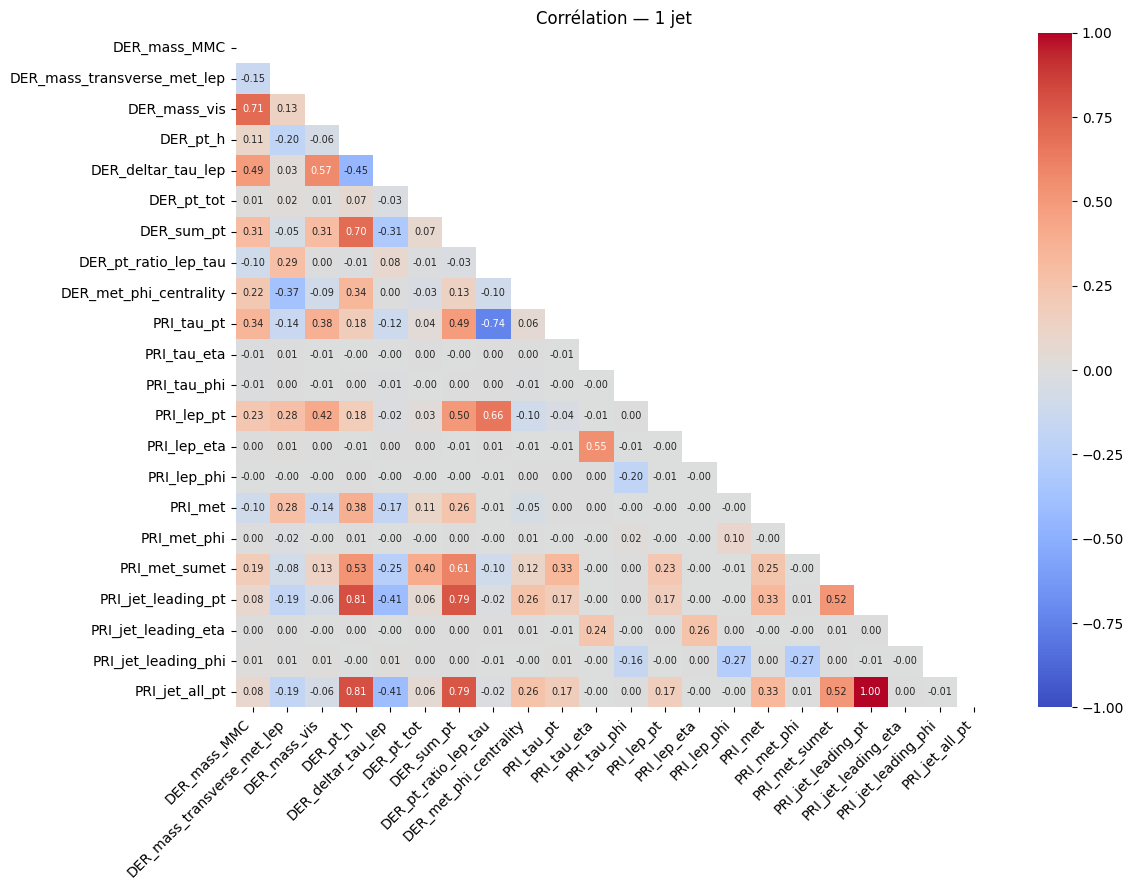

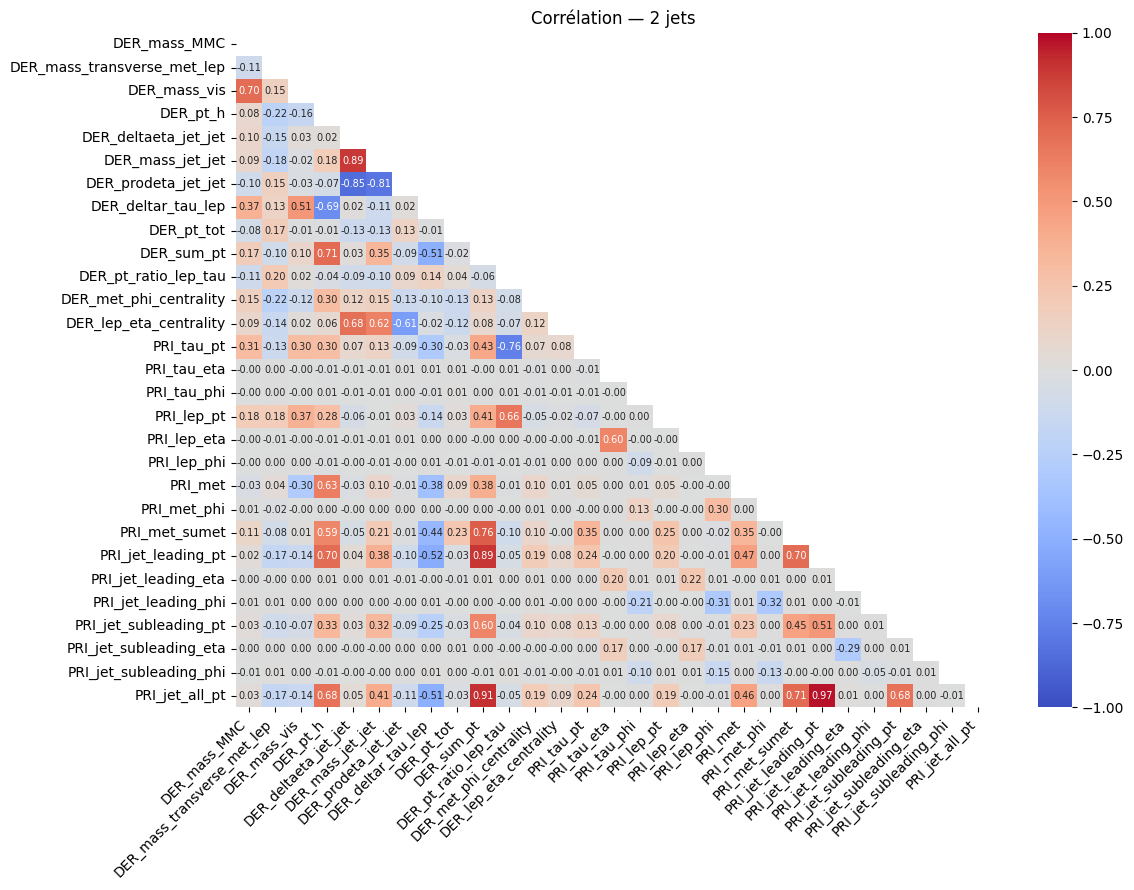

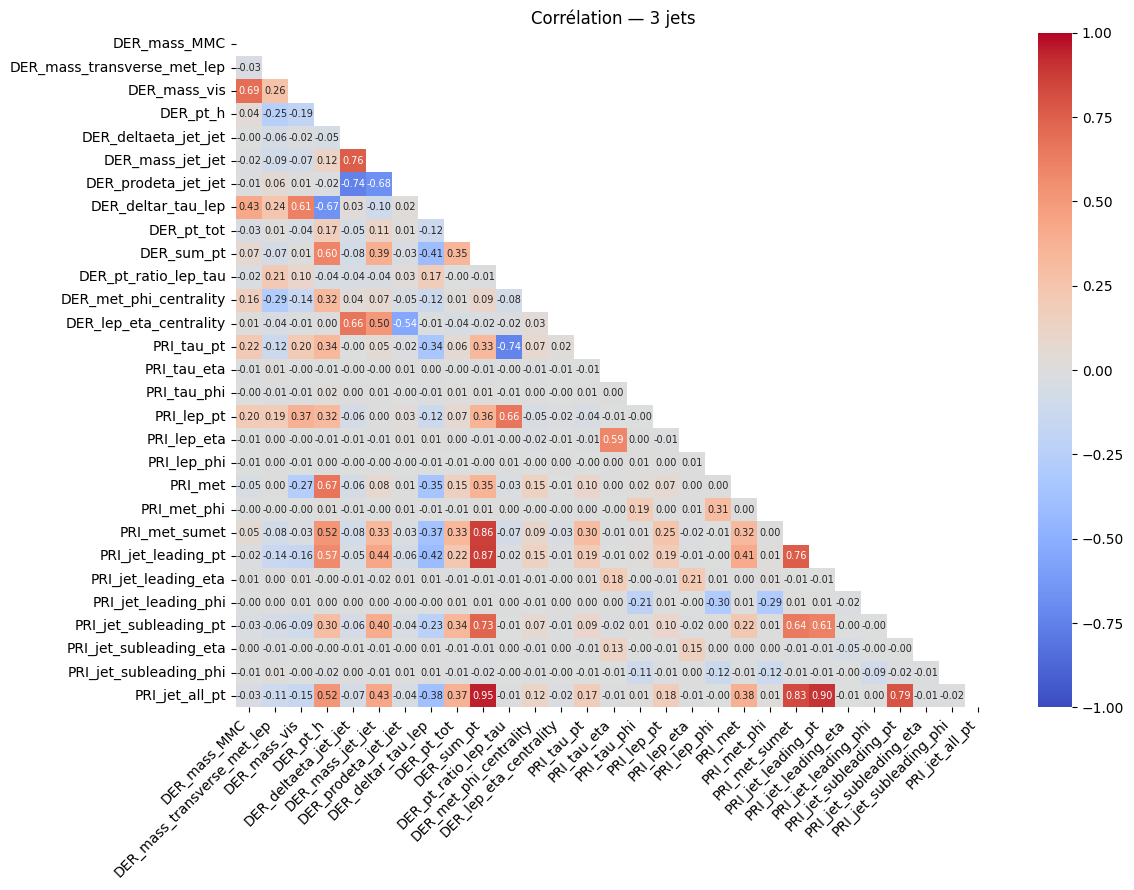

In [18]:
# Calcul et stockage des corrélations

correlations_par_jet = {}

for nom_jet, donnees_jet in donnees_par_jet.items():
    
    matrice_correlation, paires_redondantes = afficher_matrice_correlation(
        donnees_jet,
        nom_jet
    )
    
    correlations_par_jet[nom_jet] = {
        "Matrice": matrice_correlation,
        "Paires redondantes": paires_redondantes
    }

In [19]:
# Graphique combiné AUC + corrélation

def graphique_auc_correlation(auc_table, corr_matrix, nom_jet):
    
    variables = auc_table["Variable"]
    
    auc_values = []
    corr_max_values = []
    
    for var in variables:
        
        auc = auc_table.loc[
            auc_table["Variable"] == var, "AUC corrigée"
        ].values[0]
        
        # corrélation maximale avec les autres variables
        correlations = corr_matrix.loc[var].drop(var)
        corr_max = correlations.abs().max()
        
        auc_values.append(auc)
        corr_max_values.append(corr_max)
    
    # Scatter plot
    plt.figure(figsize=(8, 6))
    
    plt.scatter(auc_values, corr_max_values)
    
    # Ajout des labels
    for i, var in enumerate(variables):
        plt.text(
            auc_values[i],
            corr_max_values[i],
            var,
            fontsize=8
        )
    
    plt.xlabel("AUC corrigée")
    plt.ylabel("Corrélation maximale")
    plt.title(f"AUC vs Corrélation — {nom_jet}")
    
    # lignes guides
    plt.axvline(0.6, linestyle="--")  # seuil AUC
    plt.axhline(0.8, linestyle="--")  # seuil corrélation
    
    plt.tight_layout()
    plt.show()

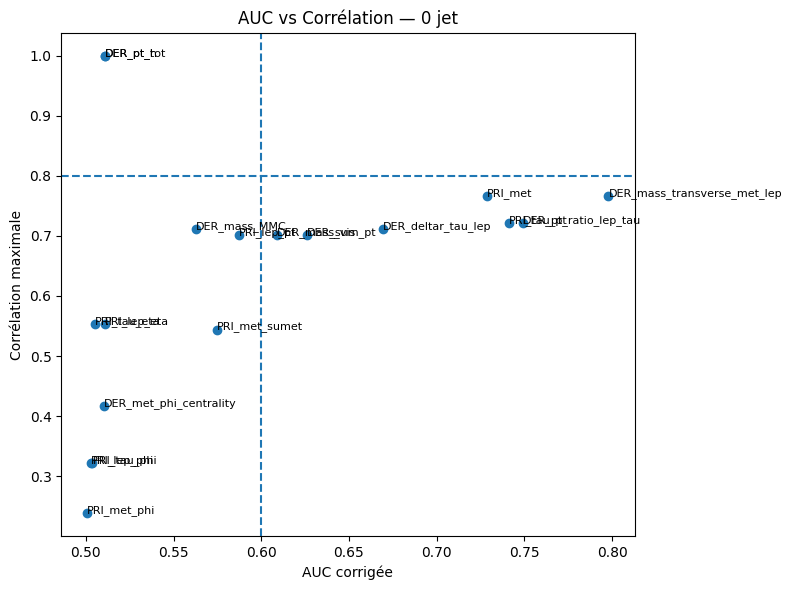

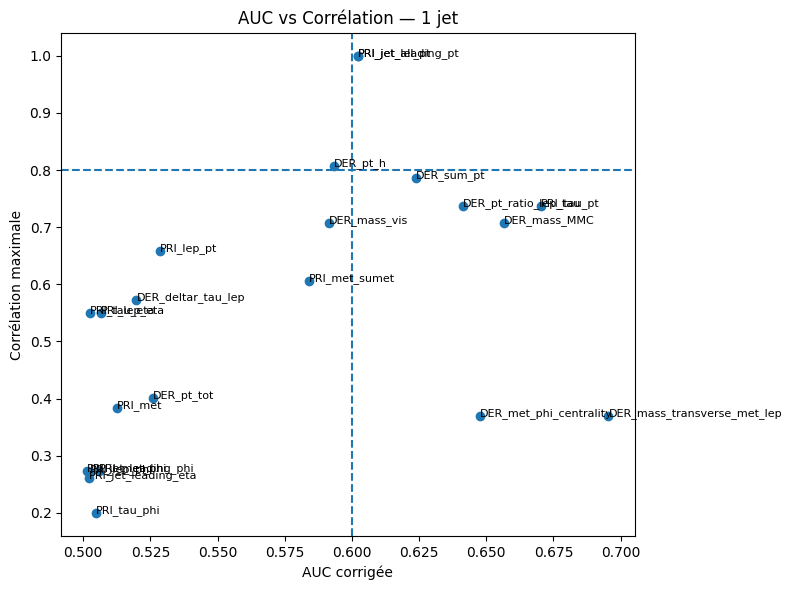

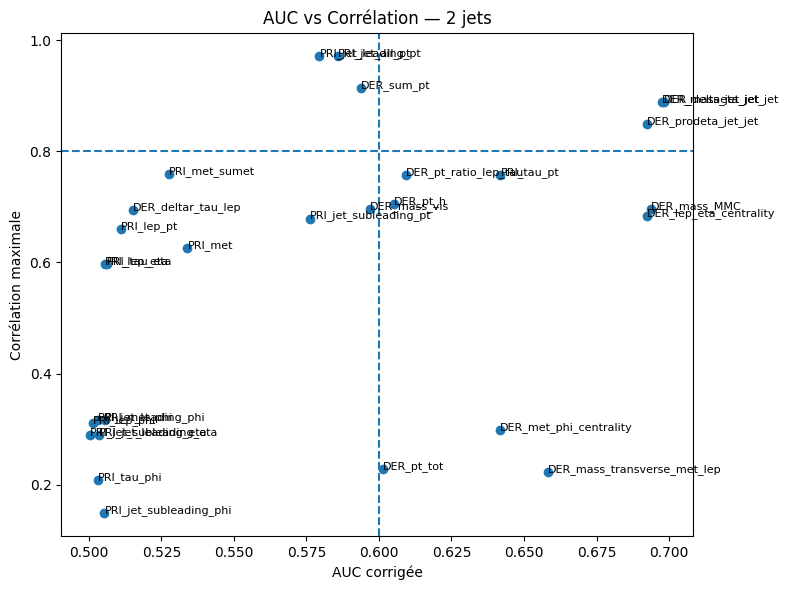

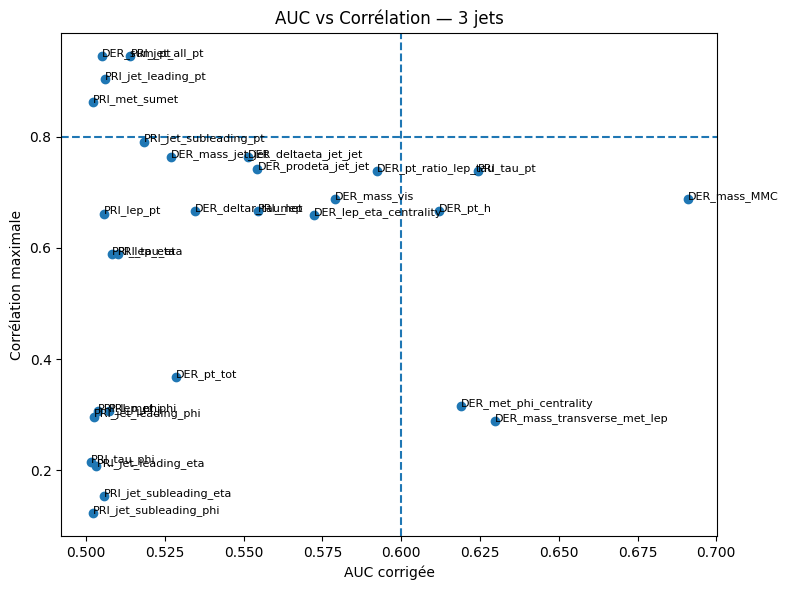

In [20]:
graphique_auc_correlation(
    auc_jet_0,
    correlations_par_jet["0 jet"]["Matrice"],
    "0 jet"
)

graphique_auc_correlation(
    auc_jet_1,
    correlations_par_jet["1 jet"]["Matrice"],
    "1 jet"
)

graphique_auc_correlation(
    auc_jet_2,
    correlations_par_jet["2 jets"]["Matrice"],
    "2 jets"
)

graphique_auc_correlation(
    auc_jet_3,
    correlations_par_jet["3 jets"]["Matrice"],
    "3 jets"
)

ANALYSE PARTICULIERE DE LA COLONNE "WEIGHT"

In [21]:
df = train.copy()
LABEL_COL = "Label"
WEIGHT_COL = "Weight"
JET_COL = "PRI_jet_num"

# Création d'une variable lisible
df["Classe"] = df[LABEL_COL].map({"s": "Signal", "b": "Bruit"})

<Figure size 800x500 with 0 Axes>

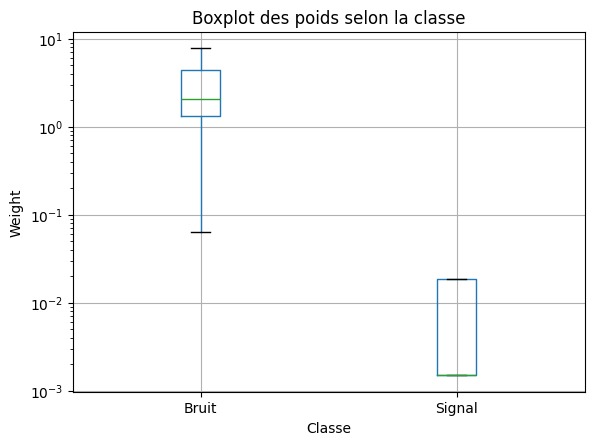

In [22]:
plt.figure(figsize=(8, 5))
df.boxplot(column=WEIGHT_COL, by="Classe")
plt.title("Boxplot des poids selon la classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Weight")
plt.yscale("log")
plt.show()

In [23]:
# Effectifs bruts
effectifs_bruts = df["Classe"].value_counts()

# Somme des poids par classe
effectifs_ponderes = df.groupby("Classe")[WEIGHT_COL].sum()

comparaison_classes = pd.DataFrame({
    "Effectif brut": effectifs_bruts,
    "Proportion brute (%)": effectifs_bruts / effectifs_bruts.sum() * 100,
    "Somme des poids": effectifs_ponderes,
    "Proportion pondérée (%)": effectifs_ponderes / effectifs_ponderes.sum() * 100
})

display(comparaison_classes)

,Effectif brut,Proportion brute (%),Somme des poids,Proportion pondérée (%)
Classe,,,,
Bruit,164333,65.7332,410999.847322,99.831916
Signal,85667,34.2668,691.988608,0.168084


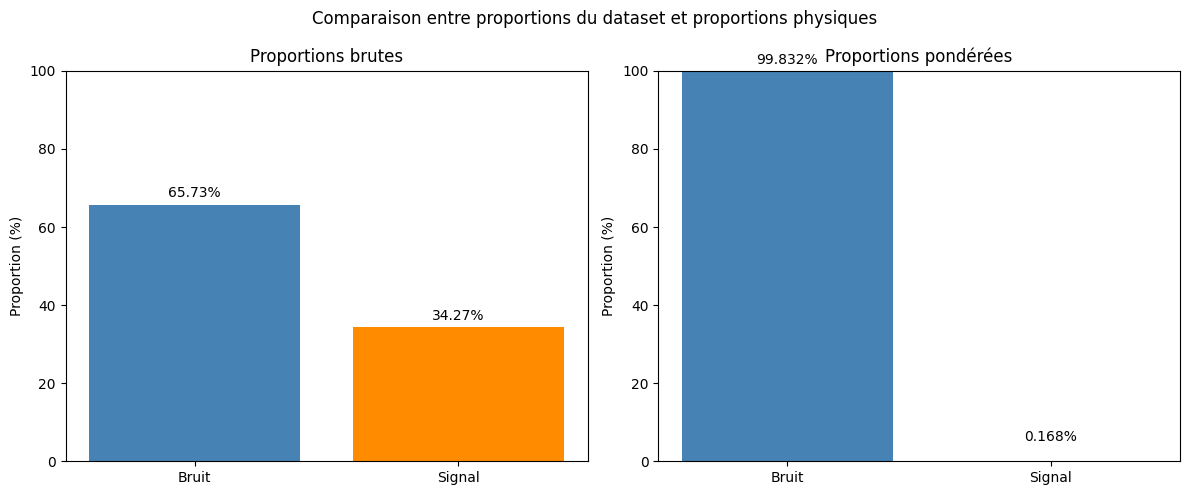

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#proportions brutes

proportions_brutes = (
    df["Classe"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

couleurs = ["steelblue", "darkorange"]

bars1 = axes[0].bar(
    proportions_brutes.index,
    proportions_brutes.values,
    color=couleurs
)

axes[0].set_title("Proportions brutes")
axes[0].set_ylabel("Proportion (%)")
axes[0].set_ylim(0, 100)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        yval + 2,
        f"{yval:.2f}%",
        ha='center'
    )


# Proportions pondérées


proportions_ponderees = (
    df.groupby("Classe")["Weight"]
    .sum()
)

proportions_ponderees = (
    proportions_ponderees /
    proportions_ponderees.sum()
) * 100

bars2 = axes[1].bar(
    proportions_ponderees.index,
    proportions_ponderees.values,
    color=couleurs
)

axes[1].set_title("Proportions pondérées")
axes[1].set_ylabel("Proportion (%)")
axes[1].set_ylim(0, 100)

for bar in bars2:
    yval = bar.get_height()
    
    # Décalage spécial pour les très petites barres
    offset = 2 if yval > 1 else 5
    
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        yval + offset,
        f"{yval:.3f}%",
        ha='center'
    )

plt.suptitle(
    "Comparaison entre proportions du dataset et proportions physiques"
)

plt.tight_layout()
plt.show()

CLASSIFICATION AVEC XGBOOST

Après l'analyse exploratoire, je passe à la classification des événements.

La sélection des variables s'appuie sur les analyses précédentes : pouvoir discriminant (AUC) et corrélations entre variables.

Le modèle utilisé ici est XGBoost. Je construis un modèle différent pour chaque groupe de jets, en conservant les poids des événements lors de l'entraînement et de l'évaluation.

In [25]:
# IMPORTATION DES BIBLIOTHEQUES NECESSAIRES A LA CLASSIFICATION
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve


DEFINITION DES VARIABLES UTILISEES POUR CHAQUE GROUPE DE JETS

In [26]:
# Les variables ont été choisies à partir des analyses d'AUC et de corrélation
# réalisées dans la première partie du notebook.

# Variables communes aux différentes catégories
features_0jet = [
    "DER_mass_MMC",
    "DER_mass_transverse_met_lep",
    "DER_mass_vis",
    "DER_pt_h",
    "DER_deltar_tau_lep",
    "DER_sum_pt",
    "DER_pt_ratio_lep_tau",
    "DER_met_phi_centrality",
    "PRI_tau_pt",
    "PRI_tau_eta",
    "PRI_lep_pt",
    "PRI_lep_eta",
    "PRI_met",
    "PRI_met_sumet"
]

# Pour 1 jet, j'ajoute les caractéristiques du jet principal.
features_1jet = features_0jet + [
    "PRI_jet_leading_pt",
    "PRI_jet_leading_eta"
]

# Pour 2 jets, j'ajoute les variables décrivant les deux jets.
# PRI_jet_all_pt n'est pas utilisée pour 1 jet.
# Certaines variables ont été retirées lorsqu'elles étaient trop redondantes.
features_2jets = [
    "DER_mass_MMC",
    "DER_mass_transverse_met_lep",
    "DER_mass_vis",
    "DER_pt_h",
    "DER_deltaeta_jet_jet",
    "DER_mass_jet_jet",
    "DER_deltar_tau_lep",
    "DER_sum_pt",
    "DER_pt_ratio_lep_tau",
    "DER_met_phi_centrality",
    "DER_lep_eta_centrality",
    "PRI_tau_pt",
    "PRI_lep_pt",
    "PRI_met_sumet",
    "PRI_jet_leading_pt",
    "PRI_jet_subleading_pt",
    "PRI_jet_all_pt"
    # DER_prodeta_jet_jet a été retirée car elle était très corrélée
    # à une autre variable (corrélation = 0.89).
]

# Pour 3 jets ou plus, je conserve la même sélection que pour 2 jets.
features = {
    0: features_0jet,
    1: features_1jet,
    2: features_2jets,
    3: features_2jets.copy()
}

# Paramètres du modèle XGBoost
XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "gamma": 1.0,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "eval_metric": "auc",
    "early_stopping_rounds": 30,
    "importance_type": "gain",
    "random_state": 42,
    "n_jobs": -1
}


ENTRAINEMENT DES MODELES POUR CHAQUE GROUPE DE JETS

In [27]:
# Copie des données utilisées pour la classification
donnees_classification = train.copy()


# Définition des sous-datasets
# Le dernier groupe regroupe les événements avec 3 jets ou plus.
sous_datasets = {
    0: donnees_classification[donnees_classification["PRI_jet_num"] == 0],
    1: donnees_classification[donnees_classification["PRI_jet_num"] == 1],
    2: donnees_classification[donnees_classification["PRI_jet_num"] == 2],
    3: donnees_classification[donnees_classification["PRI_jet_num"] >= 3]
}

# Dictionnaires permettant de conserver les modèles et les résultats
models = {}
results = {}

for nombre_jets, donnees_jet in sous_datasets.items():
    print(f"\nEntraînement du modèle pour {nombre_jets} jet(s)" if nombre_jets < 3 else "\nEntraînement du modèle pour 3 jets ou plus")

    # Variables retenues pour cette catégorie
    variables = [col for col in features[nombre_jets] if col in donnees_jet.columns]

    # Remplacement du code -999 par NaN
    # XGBoost peut alors traiter ces valeurs comme des valeurs manquantes.
    X = donnees_jet[variables].replace(-999.0, np.nan)

    # Encodage de la classe : signal = 1, bruit = 0
    y = (donnees_jet["Label"] == "s").astype(int).values

    # Récupération des poids des événements
    poids = donnees_jet["Weight"].values
    poids_normalises = poids / poids.mean()

    # Séparation entraînement / validation
    X_train, X_val, y_train, y_val, poids_train, poids_val = train_test_split(
        X,
        y,
        poids_normalises,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Création du modèle
    modele = xgb.XGBClassifier(**XGB_PARAMS)

    # Entraînement du modèle avec les poids des événements
    modele.fit(
        X_train,
        y_train,
        sample_weight=poids_train,
        eval_set=[(X_val, y_val)],
        sample_weight_eval_set=[poids_val],
        verbose=50
    )

    # Probabilité prédite pour la classe signal
    probabilites = modele.predict_proba(X_val)[:, 1]

    # AUC pondérée sur l'ensemble de validation
    auc_validation = roc_auc_score(
        y_val,
        probabilites,
        sample_weight=poids_val
    )

    # Stockage des résultats
    models[nombre_jets] = modele
    results[nombre_jets] = {
        "X_val": X_val,
        "y_val": y_val,
        "poids_val": poids_val,
        "probabilites": probabilites,
        "auc": auc_validation,
        "variables": variables,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "meilleure_iteration": modele.best_iteration + 1
    }

    print(f"AUC validation : {auc_validation:.4f}")
    print(f"Nombre de variables utilisées : {len(variables)}")
    print(f"Meilleure itération : {modele.best_iteration + 1}")



Entraînement du modèle pour 0 jet(s)
[0]	validation_0-auc:0.86878
[50]	validation_0-auc:0.92392
[100]	validation_0-auc:0.92872
[150]	validation_0-auc:0.92893
[169]	validation_0-auc:0.92893
AUC validation : 0.9289
Nombre de variables utilisées : 14
Meilleure itération : 140

Entraînement du modèle pour 1 jet(s)
[0]	validation_0-auc:0.82895
[50]	validation_0-auc:0.89099
[100]	validation_0-auc:0.89634
[150]	validation_0-auc:0.89670
[200]	validation_0-auc:0.89693
[250]	validation_0-auc:0.89702
[261]	validation_0-auc:0.89702
AUC validation : 0.8970
Nombre de variables utilisées : 16
Meilleure itération : 232

Entraînement du modèle pour 2 jet(s)
[0]	validation_0-auc:0.80457
[50]	validation_0-auc:0.90317
[100]	validation_0-auc:0.90657
[150]	validation_0-auc:0.90726
[200]	validation_0-auc:0.90729
[212]	validation_0-auc:0.90734
AUC validation : 0.9074
Nombre de variables utilisées : 17
Meilleure itération : 183

Entraînement du modèle pour 3 jets ou plus
[0]	validation_0-auc:0.73613
[50]	vali

COURBES ROC ET IMPORTANCE DES VARIABLES

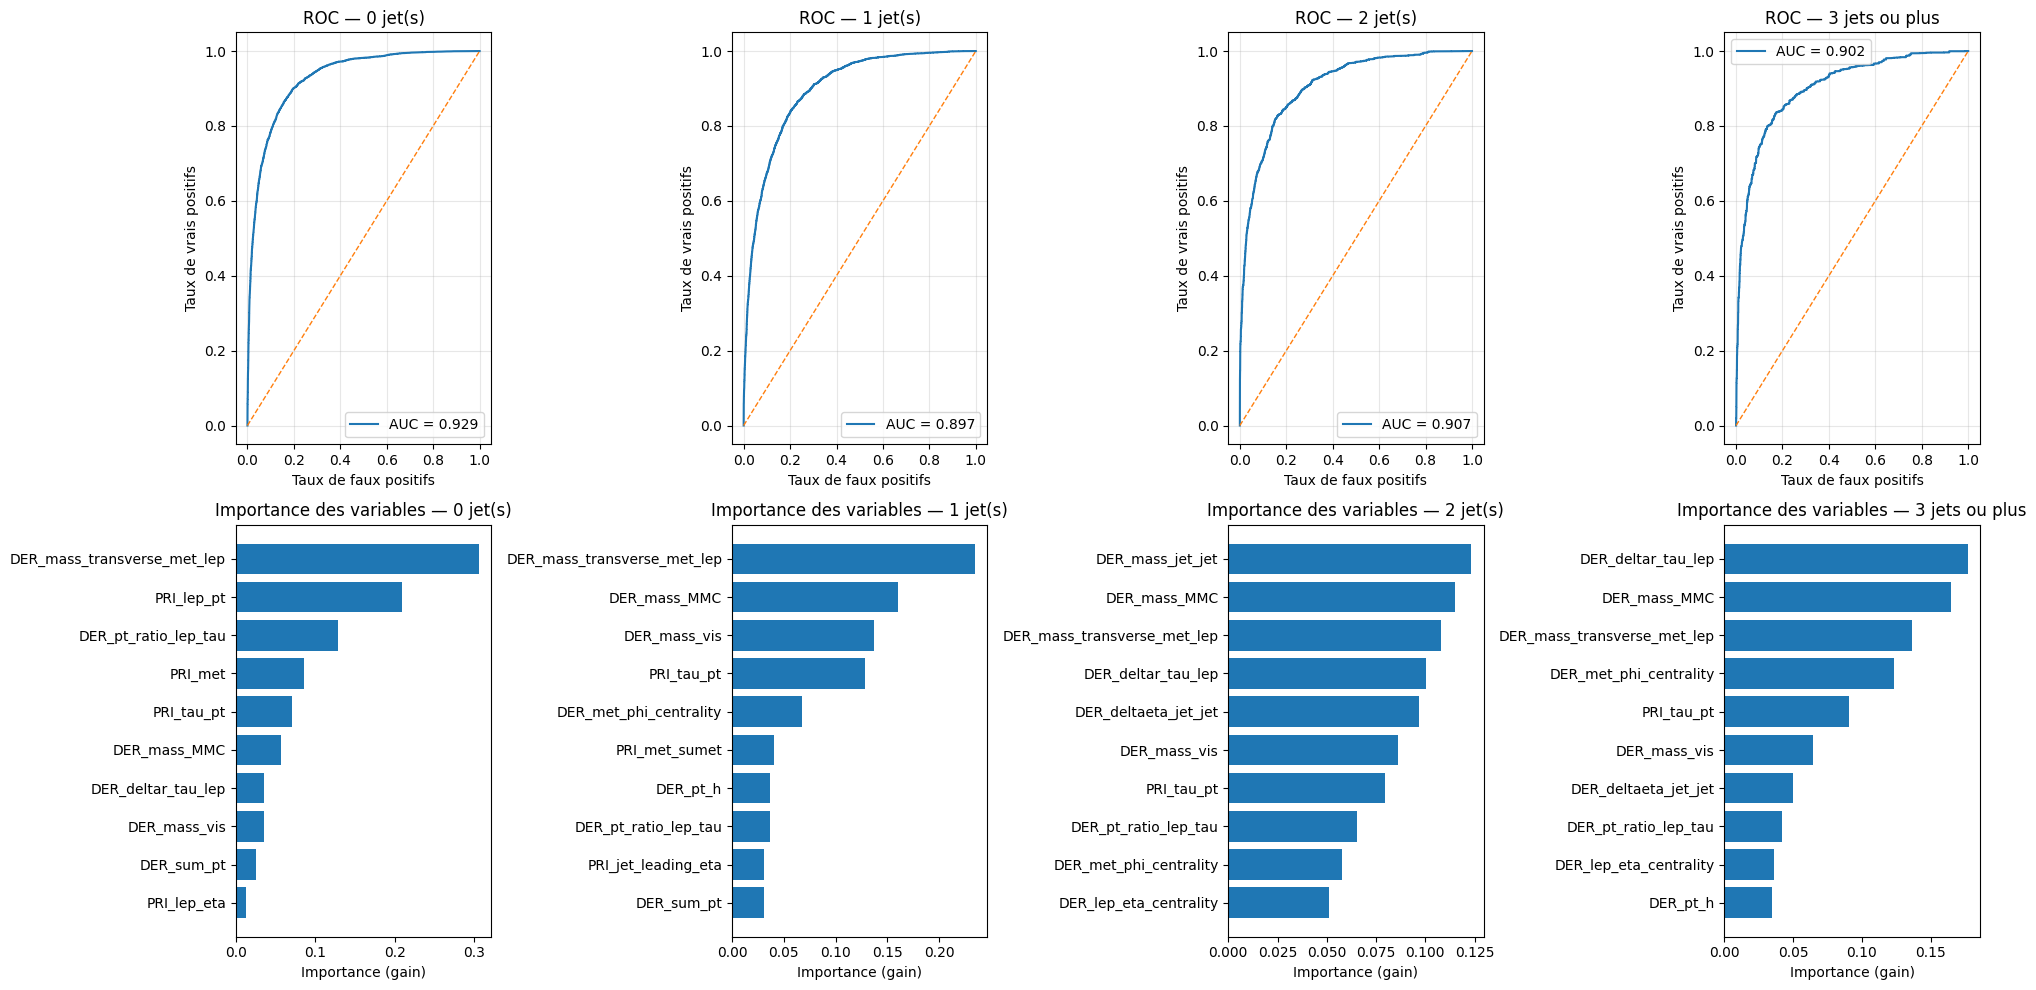

In [28]:
# Visualisation des performances et des variables importantes
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for position, nombre_jets in enumerate([0, 1, 2, 3]):
    modele = models[nombre_jets]
    resultat = results[nombre_jets]

    if nombre_jets < 3:
        nom_groupe = f"{nombre_jets} jet(s)"
    else:
        nom_groupe = "3 jets ou plus"

    # ---------- COURBE ROC ----------
    fpr, tpr, _ = roc_curve(
        resultat["y_val"],
        resultat["probabilites"],
        sample_weight=resultat["poids_val"]
    )

    axes[0, position].plot(
        fpr,
        tpr,
        label=f"AUC = {resultat['auc']:.3f}"
    )
    axes[0, position].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    axes[0, position].set_title(f"ROC — {nom_groupe}")
    axes[0, position].set_xlabel("Taux de faux positifs")
    axes[0, position].set_ylabel("Taux de vrais positifs")
    axes[0, position].legend()
    axes[0, position].grid(alpha=0.3)

    # ---------- IMPORTANCE DES VARIABLES ----------
    importances = modele.feature_importances_
    variables = resultat["variables"]

    ordre = np.argsort(importances)[-10:]

    axes[1, position].barh(
        np.array(variables)[ordre],
        importances[ordre]
    )
    axes[1, position].set_title(f"Importance des variables — {nom_groupe}")
    axes[1, position].set_xlabel("Importance (gain)")

plt.tight_layout()
plt.show()


RESUME DES RESULTATS DE LA CLASSIFICATION

In [29]:
# Tableau récapitulatif des modèles
resume_resultats = []

for nombre_jets in [0, 1, 2, 3]:
    resultat = results[nombre_jets]

    if nombre_jets < 3:
        nom_groupe = f"{nombre_jets} jet(s)"
    else:
        nom_groupe = "3 jets ou plus"

    resume_resultats.append({
        "Groupe de jets": nom_groupe,
        "Nombre de variables": len(resultat["variables"]),
        "Taille entraînement": resultat["n_train"],
        "Taille validation": resultat["n_val"],
        "Meilleure itération": resultat["meilleure_iteration"],
        "AUC validation": resultat["auc"]
    })

resume_resultats = pd.DataFrame(resume_resultats)

display(resume_resultats)


,Groupe de jets,Nombre de variables,Taille entraînement,Taille validation,Meilleure itération,AUC validation
0,0 jet(s),14,79930,19983,140,0.928933
1,1 jet(s),16,62035,15509,232,0.897017
2,2 jet(s),17,40303,10076,183,0.907392
3,3 jets ou plus,17,17731,4433,143,0.902109
